# 04 — `src/data/harespod_loader.py`: The Real-Data Adapter

Unlike every other notebook in this series, this module's job **hasn't been fully exercised yet** — because the real Harespod dataset hasn't been downloaded (it's a manual Figshare browser download, not something the pipeline can fetch on its own; see the download steps you were given separately).

This notebook explains what the loader is *for*, what it does today, and exactly what will happen the moment you drop the real files into `data/raw/harespod/`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from src.data import harespod_loader
from src.config import HARESPOD_DIR

## Why this file exists before the data does

CLAUDE.md's decision log records "synthetic-first, adapter ready" — rather than blocking Days 1-7 on a manual download, we built the *entire* dataset/feature/model pipeline against the synthetic generator (`synth_data.py`), while writing this loader against Harespod's **documented** schema (100Hz SpO2/HR/respiration from 15 subjects in a hypobaric chamber, per the Figshare DOI and the `oca-john/Harespod` companion repo). The goal: the moment you download the real files, this module should start producing real data with **zero changes needed anywhere else in the pipeline** — `feature_engineering.py`, all three models, and the metrics all consume the same tidy DataFrame shape regardless of which loader produced it.

In [2]:
print("Expected location: ", HARESPOD_DIR)
print("Currently exists:  ", HARESPOD_DIR.exists())
print("Has data:          ", harespod_loader.has_harespod_data())

Expected location:  C:\Users\shaur\Desktop\My codes shaurya\Medical Alert System\data\raw\harespod
Currently exists:   True
Has data:           False


## `has_harespod_data()` — the cheap existence check

```python
def has_harespod_data() -> bool:
    if not HARESPOD_DIR.exists():
        return False
    return any(HARESPOD_DIR.iterdir())
```

This returns `False` rather than raising an exception, specifically so other code (like a future data-merge script that wants to "use Harespod if present, else pure synthetic") can branch on it with a plain `if` instead of wrapping every call in `try/except`. You saw this pattern already in `feature_engineering.run_pipeline()`'s comment about where the Harespod merge will eventually plug in.

## What happens right now if you try to load data

If you call `load_subject()` or `load_all_subjects()` before the files exist, you don't get a cryptic pandas error three stack frames deep — you get a clear, actionable message telling you exactly what to do.

In [3]:
try:
    harespod_loader.load_all_subjects()
except FileNotFoundError as e:
    print(e)

Harespod data not found in data/raw/harespod/.

This is expected if you haven't downloaded it yet -- it's a manual browser download, not something this pipeline fetches automatically.

To get it:
  1. Visit https://doi.org/10.6084/m9.figshare.c.6623344.v1
  2. Download the dataset archive and unzip its contents into
     C:\Users\shaur\Desktop\My codes shaurya\Medical Alert System\data\raw\harespod
  3. (Optional) companion loading code: https://github.com/oca-john/Harespod

Until then, the rest of the pipeline runs on the synthetic generator (src/data/synth_data.py) instead -- see CLAUDE.md Section 5.


## `interpolate_altitude()` — filling in Harespod's biggest gap

Harespod is a **hypobaric chamber** study — the "altitude" isn't a continuous sensor reading like it would be on a real mountain, it's a series of discrete pressure-change events the chamber operators trigger (e.g. "at t=120s, set chamber altitude to 4000m"). Our synthetic data and any real ascent both produce smooth, continuous altitude curves, so before Harespod's altitude markers can be fed into the same `feature_engineering.py` that expects a continuous column, they need to be interpolated.

```python
def interpolate_altitude(df, altitude_markers):
    marker_times = np.array([t for t, _ in altitude_markers])
    marker_alts = np.array([a for _, a in altitude_markers])
    return pd.Series(np.interp(df["timestamp"], marker_times, marker_alts), ...)
```

This uses `np.interp` to linearly interpolate *between* known marker points — a straight line from one known altitude/time pair to the next. It's an approximation (assumes a steady climb/descent rate between two markers), but it's the reasonable assumption for a chamber protocol that ramps pressure smoothly over a few minutes between steps, rather than jumping instantly.

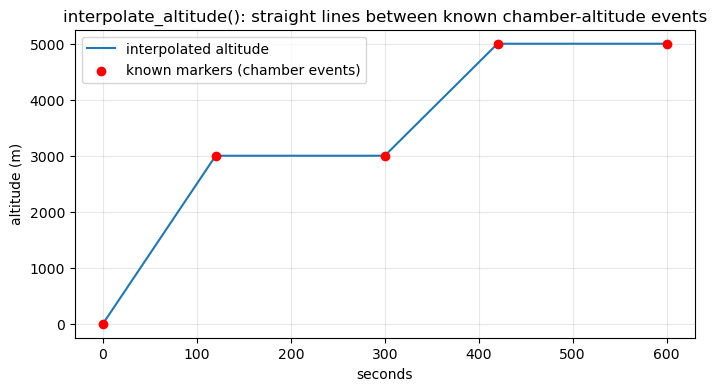

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Demo with synthetic markers standing in for what real Harespod chamber events might look like
demo_df = pd.DataFrame({"timestamp": np.arange(0, 600, 1.0)})
markers = [(0, 0), (120, 3000), (300, 3000), (420, 5000), (600, 5000)]  # (time_s, altitude_m)

interpolated = harespod_loader.interpolate_altitude(demo_df, markers)

plt.figure(figsize=(8, 4))
plt.plot(demo_df["timestamp"], interpolated, label="interpolated altitude")
marker_t, marker_a = zip(*markers)
plt.scatter(marker_t, marker_a, color="red", zorder=5, label="known markers (chamber events)")
plt.xlabel("seconds")
plt.ylabel("altitude (m)")
plt.title("interpolate_altitude(): straight lines between known chamber-altitude events")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## `load_subject()` and downsampling

Harespod records at 100Hz; our whole pipeline (and a realistic Arduino) operates at 1Hz (`config.SAMPLE_RATE_HZ`). The loader downsamples by taking a stride:

```python
stride = HARESPOD_RAW_HZ // SAMPLE_RATE_HZ   # = 100
downsampled = raw.iloc[::stride].reset_index(drop=True)
```

**Why stride instead of averaging every 100 samples down to 1?** Averaging would smooth out the real sensor noise present in each individual reading — but our XGBoost/LSTM models need to learn to handle noisy readings, because that's what the real Arduino will actually produce. If we trained on artificially-smoothed data, the models would be *too* confident about clean signals and could perform worse on the genuinely noisy hardware stream later. Taking a stride (literally picking every 100th sample) preserves the true per-sample noise character instead.

In [5]:
# Illustration of the stride-vs-average distinction using synthetic noisy data
rng = np.random.default_rng(0)
fake_100hz = pd.Series(50 + rng.normal(0, 3, 1000))  # noisy signal, mean 50, std 3

strided = fake_100hz.iloc[::100].reset_index(drop=True)
averaged = fake_100hz.groupby(np.arange(len(fake_100hz)) // 100).mean().reset_index(drop=True)

print("Original (100Hz) std: ", round(fake_100hz.std(), 2))
print("Strided (1Hz) std:    ", round(strided.std(), 2), " <- preserves real per-sample noise")
print("Averaged (1Hz) std:   ", round(averaged.std(), 2), " <- artificially smoothed, understates noise")

Original (100Hz) std:  2.93
Strided (1Hz) std:     2.81  <- preserves real per-sample noise
Averaged (1Hz) std:    0.29  <- artificially smoothed, understates noise


## What's still a placeholder

The loader's docstring is explicit about this: `load_subject()`'s file-reading logic (`HARESPOD_DIR / f"{subject_id}.csv"`) is a **guess** at the naming convention, since we haven't inspected the real archive yet. Once you download it:

1. I'll look at the actual file names/format (checking the `oca-john/Harespod` companion repo's own loading code for reference).
2. I'll adjust the file-reading logic in `load_subject()` to match.
3. The **output contract stays the same** (`TIDY_COLUMNS = ["timestamp", "spo2", "hr", "resp", "altitude", "subject_id"]`) — so nothing in `feature_engineering.py`, the models, or this notebook's explanations needs to change. Only the "how do I read the raw file" part gets filled in.

## Summary

This module is a contract, written ahead of the data it will eventually load: *whatever the real Harespod files look like, `load_all_subjects()` will hand back a tidy 1Hz DataFrame with the same shape the synthetic generator produces.* That's what makes "drop in the real data with no other changes" possible.

**Next notebook:** `05_feature_engineering.ipynb` — turning raw vitals (synthetic or, later, real) into the trend/delta features the models actually train on.